<div align="center">

#  Week 6 – Natural Language Processing (NLP)

## SMS Spam Detection

### 📘 Text Classification using Machine Learning

---

### Objective

Natural Language Processing (NLP) enables computers to understand and process human language.

In this project, we will build a machine learning model capable of classifying SMS messages as **Spam** or **Ham (Not Spam)**.

The project consists of:

- Text Preprocessing
- Feature Extraction
- Machine Learning Classification
- Model Evaluation

</div>

In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


# Loading the Dataset

The SMS Spam Collection dataset contains text messages labelled as either:

- Ham (Normal Message)
- Spam (Unwanted Message)

This dataset will be used for text classification.

In [16]:
df = pd.read_csv("spam.csv", encoding="latin-1")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [17]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [19]:
df.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [20]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

# Keeping Required Columns

The original dataset contains extra columns that are not required.

We will retain only:

- Label
- Message

In [21]:
df = df.iloc[:, :2]

df.columns = ["Label", "Message"]

df.head()

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# Message Distribution

Let's see how many messages belong to each category.

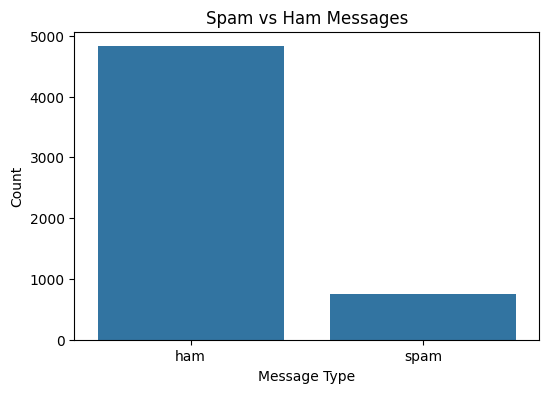

In [22]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Label")

plt.title("Spam vs Ham Messages")

plt.xlabel("Message Type")

plt.ylabel("Count")

plt.savefig("Visualizations/message_distribution.png")

plt.show()

# Converting Text to Lowercase

Converting text to lowercase ensures that words like **Free**, **FREE**, and **free** are treated as the same word.

In [23]:
df["Message"] = df["Message"].str.lower()

df.head()

,Label,Message
0,ham,"go until jurong point, crazy.. available only ..."
1,ham,ok lar... joking wif u oni...
2,spam,free entry in 2 a wkly comp to win fa cup fina...
3,ham,u dun say so early hor... u c already then say...
4,ham,"nah i don't think he goes to usf, he lives aro..."


# Removing Punctuation

In [24]:
import string

df["Message"] = df["Message"].str.translate(
    str.maketrans("", "", string.punctuation)
)

df.head()

,Label,Message
0,ham,go until jurong point crazy available only in ...
1,ham,ok lar joking wif u oni
2,spam,free entry in 2 a wkly comp to win fa cup fina...
3,ham,u dun say so early hor u c already then say
4,ham,nah i dont think he goes to usf he lives aroun...


In [25]:
# removing numbers from the text
df["Message"] = df["Message"].str.replace(r"\d+", "", regex=True)

df.head()

,Label,Message
0,ham,go until jurong point crazy available only in ...
1,ham,ok lar joking wif u oni
2,spam,free entry in a wkly comp to win fa cup final...
3,ham,u dun say so early hor u c already then say
4,ham,nah i dont think he goes to usf he lives aroun...


In [26]:
# removing exra spaces from the text


df["Message"] = df["Message"].str.replace(r"\s+", " ", regex=True).str.strip()

df.head()

,Label,Message
0,ham,go until jurong point crazy available only in ...
1,ham,ok lar joking wif u oni
2,spam,free entry in a wkly comp to win fa cup final ...
3,ham,u dun say so early hor u c already then say
4,ham,nah i dont think he goes to usf he lives aroun...


# 💡 Observation

The text has now been cleaned by:

- Converting to lowercase
- Removing punctuation
- Removing numbers
- Removing extra spaces

The cleaned text is now ready for feature extraction and machine learning.